# Exercise 2 — Flood impact for one storm of the flood-map library — Moroni, Comoros

The UFFIS forecast for the Comoros does not run a hydraulic model when a storm
approaches. Instead each of the 55 ADM3 communes has a **library of 200 synthetic
storms**, each with a precomputed maximum flood-depth map, and the forecast picks from
it. This notebook opens the library for **Moroni** — the capital, on Grande Comore —
takes one storm out of it and works out what its flood actually touches: how deep the
water gets on each individual building and road, and how many people, how much floor
area and how many kilometres of road that adds up to.

The question being answered is:

> **In storm 150, how deep is the water on each building and road in Moroni?**

Depth is a physical quantity, so the answer needs no reference to a threshold — worth
contrasting with Exercise 3, which works from *probabilities* across a forecast and
therefore does need one. Section 9 shows how the two connect, and for the Comoros it
can be checked against the published product rather than merely described.

**What is particular to the Comoros**

- **Pluvial only.** The island models were run with rainfall forcing and no upstream
  boundary discharge, so `hazards_enabled` in the run summary reads
  `pluvial: true, fluvial: false`. Flooding here is rain that has not drained, never a
  river rising.
- **A projected grid.** Everything sits in EPSG:5629 (Moznet / UTM zone 38S) at
  30.57 m. Cells are square metres, so areas need no latitude correction — unlike the
  arc-second grids used for Antigua and Barbuda.
- **Depth does not saturate.** The Comoros libraries store float metres at 1 cm
  precision, so the deep bands mean what they say. The Antigua and Barbuda and
  Barbados libraries pack depth into a byte and top out at 2.55 m.

**What to take away from it**

- how to read one slice out of a large Zarr store without pulling the whole array
- how to sample a raster onto tens of thousands of polygons in a single pass, why the
  *maximum* over a footprint is the defensible choice, and how to notice when a
  sampling method is not fit for the grid
- where each number in an impact table comes from, and which decisions along the way
  change it
- how a forecast turns a library of scenarios into the probability rasters of
  Exercise 3 — and how to verify that you have the rule right

**Workflow**

1. Open the storm library and look at one storm
2. Read the storm index: which storms exist and how big they are
3. Load the buildings and roads of Moroni
4. Sample the deepest water on each feature's own footprint
5. Group into depth bands and build the impact table
6. Map it
7. See how impact grows across the library
8. From library to forecast: rebuild Exercise 3's raster and check it

Everything is read from a public S3 bucket. Nothing needs to be downloaded first
except the receptor geopackage.

In [1]:
import sys

# Google Colab ships geopandas but not zarr 3, rasterio or pyogrio. A local
# environment made with `pip install -e .` from the plugin repo has everything.
if "google.colab" in sys.modules:
    %pip install -q "zarr>=3" rasterio pyogrio

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import zarr
from zarr.storage import FsspecStore

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"

# One store per commune, and one receptor geopackage per island. Naming the commune
# fixes both, because the pcode prefix says which island it sits on.
UNIT = "KM274_Moroni"
PCODE = UNIT.split("_")[0]
ISLAND = "grande"

STORE = f"{BUCKET}/Comoros_IBF/Comoros/fim_store_{UNIT}_v1.zarr"

CYCLE_ROOT = (
    f"{BUCKET}/Comoros_training/Comoros_cycle_20240427_0000UTC"
    "/Comoros_cycle_20240427_0000UTC"
)
CYCLE = "20240427.000000"
FEATURES = f"{CYCLE_ROOT}/ibf/receptors_{ISLAND}_{CYCLE}.gpkg"

print(f"store {STORE.rsplit('/', 1)[-1]}")

store fim_store_KM274_Moroni_v1.zarr


## 1. The storm library

The flood maps live in a **Zarr store** — an array split into many small files, so
you can read one slice without downloading the whole thing. The `depth` array here is
200 storms × 198 rows × 169 columns of float32; we only ever want one storm at a time.

The store carries its own metadata. Read that first: it tells you where you are, what
units you are in, and what *not* to trust.

In [3]:
group = zarr.open_group(FsspecStore.from_url(STORE), mode="r")
attrs = dict(group.attrs)

for key, value in attrs.items():
    print(f"{key:22} {value}")

crs                    EPSG:5629
transform              [30.574982601394, 0.0, 307199.7378100209, 0.0, -30.574982601394, 8708607.441862924]
extent_threshold_m     0.05
source_nodata          None
magnitude_source       real RainyDay storm totals: area weighted mean over the municipality of the band summed Comoros_NE_No1 scenario rain geotiff (200 scenarios, 72 bands, 0.027 degree grid)
n_storms               200
grid_shape             [198, 169]
depth_source           grande island model maximum depth rasters (float64 metres), stored at 1 cm precision
admin_unit             {'pcode': 'KM274', 'name': 'Moroni', 'adm1': 'Grande Comore (Ngazidja)', 'adm2': 'Moroni-Bambao'}


Four things to take from that:

- **`admin_unit`** — Moroni (KM274), in Moroni-Bambao on Grande Comore (Ngazidja).
  Every commune has its own store, windowed on the commune plus a ten-cell buffer;
  there are 55 of them.
- **`extent_threshold_m: 0.05`** — the model does not consider a cell wet below 5 cm.
  We will reuse that number rather than inventing our own.
- **`magnitude_source`** — *"real RainyDay storm totals"*, area-weighted over the
  commune from the `Comoros_NE_No1` scenario rain grid. The area weighting matters
  here: the rain grid is about 3 km and several Comorian communes are only a few rain
  cells across, so a plain cell-centre mask would bias or empty the smallest ones.
  Because the magnitude is a measured property of the scenario, plotting impact
  against it is legitimate.
- **`depth_source`** — *"float64 metres, stored at 1 cm precision"*. Note what is
  **not** here: no byte packing, and so no 2.55 m ceiling. The Antigua and Barbuda and
  Barbados libraries do have one, and their top depth band cannot be trusted to be
  distinct. This one can.

`depth` is in **metres**, and `transform` + `crs` place each cell: EPSG:5629 at
30.57 m, the island model's own grid, on the same lattice as the probability rasters
of Exercise 3.

In [4]:
depth = group["depth"]
print(f"depth array: shape {depth.shape}  dtype {depth.dtype}  chunks {depth.chunks}")
print(f"  -> {depth.nbytes / 1e6:.0f} MB in total, "
      f"{np.prod(depth.chunks) * 4 / 1e3:.0f} KB per storm before compression")

STORM = 150                      # try changing this: 0-2 are the dry baseline, 199 the largest
one_storm = np.asarray(depth[STORM], dtype="float32")
one_storm = np.where(np.isfinite(one_storm) & (one_storm > 0), one_storm, 0.0)

wet = one_storm[one_storm >= attrs["extent_threshold_m"]]
print(f"\nstorm {STORM}: {wet.size:,} wet cells, "
      f"max {one_storm.max():.2f} m, mean where wet {wet.mean():.2f} m")

depth array: shape (200, 198, 169)  dtype float32  chunks (1, 198, 169)
  -> 27 MB in total, 134 KB per storm before compression



storm 150: 12,866 wet cells, max 1.69 m, mean where wet 0.14 m


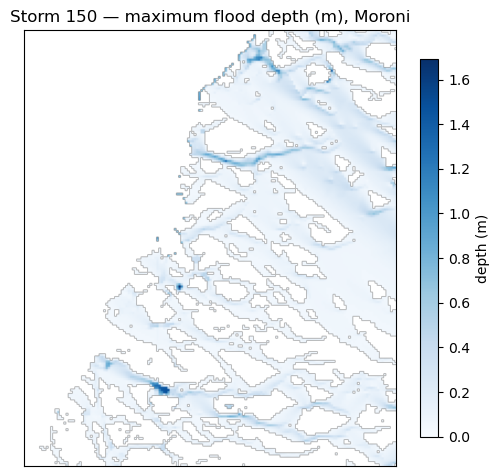

In [5]:
fig, ax = plt.subplots(figsize=(6, 7))
shown = np.where(one_storm >= attrs["extent_threshold_m"], one_storm, np.nan)
im = ax.imshow(shown, cmap="Blues", vmin=0, vmax=float(one_storm.max()))
ax.set_title(f"Storm {STORM} — maximum flood depth (m), {attrs['admin_unit']['name']}")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label="depth (m)", shrink=0.7)
plt.show()

## 2. The storm index

Storm 150 is a position, not a name. The store's `index.csv` maps each position to the
scenario it came from (`storm_id`) and its rainfall total (`magnitude_mm`), sorted by
magnitude — so stepping through the positions walks *severity*.

The grid is projected, so a cell is simply `resolution²` and the flooded area needs no
latitude correction. Reading `extent` (a 0/1 wet mask) is cheaper than reading depth,
so the sweep below uses it.

200 storms, rainfall totals 0.01 to 1029.7 mm, sorted: True


,storm_index,storm_id,magnitude_mm
0,0,sample_0091,0.01
1,1,sample_0035,0.03
2,2,sample_0003,0.05
100,100,sample_0136,282.68
150,150,sample_0148,422.75
199,199,sample_0199,1029.70


cell 30.57 m -> 935 m² each


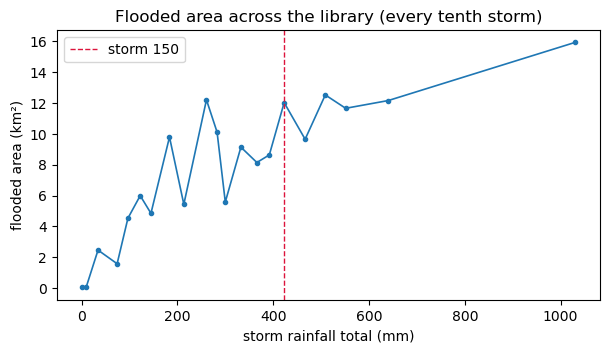

In [6]:
index = pd.read_csv(f"{STORE}/index.csv")
print(f"{len(index)} storms, rainfall totals {index.magnitude_mm.min():g} to "
      f"{index.magnitude_mm.max():g} mm, sorted: {index.magnitude_mm.is_monotonic_increasing}")
display(index.iloc[[0, 1, 2, 100, 150, 199]])

# Projected grid: the cell is square metres, no cos(latitude) anywhere.
cell_m2 = attrs["transform"][0] ** 2
print(f"cell {attrs['transform'][0]:.2f} m -> {cell_m2:,.0f} m² each")

sample = list(range(0, 200, 10)) + [199]
extent = group["extent"]
area_km2 = [np.asarray(extent[i]).sum() * cell_m2 / 1e6 for i in sample]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(index.magnitude_mm[sample], area_km2, marker="o", ms=3, lw=1.2)
ax.axvline(index.magnitude_mm[STORM], color="crimson", ls="--", lw=1, label=f"storm {STORM}")
ax.set_xlabel("storm rainfall total (mm)"); ax.set_ylabel("flooded area (km²)")
ax.set_title("Flooded area across the library (every tenth storm)")
ax.legend(); plt.show()

The curve does not start at zero. The driest storms in the library carry a rainfall
total of a few hundredths of a millimetre and still show a small standing footprint —
that is Moroni's **permanent water**, not flood signal, and it is the same baseline the
overbank reference of the site config exists to remove. Exercise 3 reads the
`pluvial_overbank` rasters for exactly this reason. Watch for it whenever the shallow
end of a library looks wetter than it should.

## 3. The buildings and roads of Moroni

The exposure data is the IBF receptor geopackage for **Grande Comore** — 131,219
buildings and 4,784 road segments, with the four exceedance probabilities of
Exercise 3 already attached. One file covers all 29 communes on the island, so the
read is filtered on the commune code before anything leaves the file.

Reading a 47 MB geopackage straight off HTTPS goes through GDAL's `/vsicurl`, which
range-requests the file once per layer; downloading it once is much faster.

In [7]:
import os
import tempfile
import urllib.request
from pathlib import Path

import pyogrio


def cached(url):
    """Fetch once into the temp dir and return the local path.

    The transfer lands on a staging name and is moved into place only once it is
    complete, so an interrupted download cannot leave a truncated file cached under
    the real name -- GDAL reports that one as "database disk image is malformed" on
    every later run, and deleting it by hand is the only cure.
    """
    path = Path(tempfile.gettempdir()) / url.rsplit("/", 1)[-1]
    if not path.exists():
        fd, staged = tempfile.mkstemp(dir=path.parent, prefix=f"{path.name}.", suffix=".part")
        os.close(fd)
        try:
            urllib.request.urlretrieve(url, staged)
            os.replace(staged, path)
        finally:
            Path(staged).unlink(missing_ok=True)
    return path


source = cached(FEATURES)
LAYERS = {
    "building": ("buildings",
                 ["feature_id", "subtype", "residential_class", "critical",
                  "final_area_weight", "population_per_building", "building_area_m2"]),
    "road": ("roads", ["feature_id", "road_class", "road_length_m"]),
}

parts = []
for type_, (layer, columns) in LAYERS.items():
    part = pyogrio.read_dataframe(source, layer=layer, columns=columns,
                                  where=f"ADM3_PCODE = '{PCODE}'", use_arrow=True)
    part["type"] = type_
    parts.append(part)
features = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)

# A road has no population and a building no length: fill so every row sums.
for col in ["population_per_building", "building_area_m2", "road_length_m"]:
    features[col] = features[col].fillna(0.0)

print(f"{len(features):,} features in {attrs['admin_unit']['name']}  |  "
      f"CRS {features.crs.to_string()}")
print(features["type"].value_counts().to_string())
print()
features[["type", "subtype", "population_per_building", "building_area_m2", "road_length_m"]].head(3)

25,272 features in Moroni  |  CRS EPSG:5629
type
building    24497
road          775



,type,subtype,population_per_building,building_area_m2,road_length_m
0,building,None,2.92,83.88,0.0
1,building,None,0.51,14.60,0.0
2,building,None,1.67,48.03,0.0


`population_per_building` is a **per-building** estimate, not a census count: the
commune population spread over its buildings by built-up area, which is what
`final_area_weight` records. The right check on a disaggregated field is that it adds
back up to the total it came from — and here it does, to within a rounding error of
the commune table shipped with the cycle.

That check is worth running every time. A population column that is secretly a
*total* repeated on every row will sum to something enormous and entirely plausible
looking; the Antigua and Barbuda package ships exactly such a trap next to the real
column.

In [8]:
buildings = features[features["type"] == "building"]
communes = pd.read_csv(f"{CYCLE_ROOT}/ibf/communes_{CYCLE}.csv")
official = communes.loc[communes.ADM3_PCODE == PCODE, "population"].iloc[0]

print(f"sum of population_per_building : {buildings.population_per_building.sum():>12,.0f}")
print(f"commune population, communes_{CYCLE}.csv : {official:>12,.0f}")
print(f"sum of road_length_m           : {features.road_length_m.sum() / 1000:>12,.1f} km")
print(f"rd_len_m from the same table   : {communes.loc[communes.ADM3_PCODE == PCODE, 'rd_len_m'].iloc[0] / 1000:>12,.1f} km")

sum of population_per_building :       69,669
commune population, communes_20240427.000000.csv :       69,668
sum of road_length_m           :         82.5 km
rd_len_m from the same table   :         82.5 km


## 4. Sampling depth onto each feature

We want, for each building, **the deepest water anywhere on its footprint**. That is
the conservative reading, and it matches how the IBF probabilities in Exercise 3 were
sampled, so the two products stay comparable.

Doing this one feature at a time would be slow, and the usual shortcut — burn each
feature's id into a grid once, then read depths back by id — does not work here. At
30 m a cell is bigger than most buildings in Moroni, and many buildings share one
cell, so burning ids keeps only the last one and silently drops the rest. The grid is
coarse relative to the features, so the sampling has to allow **many features per
cell**.

Instead, build the list of (feature, cell) pairs once:

1. For each feature, take the cells its bounding box covers — a handful each.
2. Keep only the pairs where the feature actually touches the cell. This is a
   vectorised intersection test, so it is one call, not 25,000.
3. For each storm, take the maximum depth per feature over its pairs with
   `np.maximum.at`, a single pass over the pairs.

Only step 3 depends on the storm, so steps 1 and 2 are paid once and reused for all
200. The reprojection below is a no-op — receptors and store are both EPSG:5629,
because nothing in the Comoros package is a reprojected copy — but it is kept, because
nothing in the data guarantees that and a silent mismatch puts every feature off the
grid.

In [9]:
import shapely

zarr_transform = rasterio.Affine(*attrs["transform"])
rows, cols = attrs["grid_shape"]
features = features.to_crs(attrs["crs"])

# 1. The cells each feature's bounding box covers. Row 0 is the top edge and the
#    cell height `e` is negative, so the first row comes from the *maximum* y.
a, _, x0, _, e, y0 = zarr_transform[:6]
minx, miny, maxx, maxy = features.geometry.bounds.to_numpy().T
c0 = np.clip(np.floor((minx - x0) / a).astype(int), 0, cols - 1)
c1 = np.clip(np.floor((maxx - x0) / a).astype(int), 0, cols - 1)
r0 = np.clip(np.floor((maxy - y0) / e).astype(int), 0, rows - 1)
r1 = np.clip(np.floor((miny - y0) / e).astype(int), 0, rows - 1)

n_cells = (r1 - r0 + 1) * (c1 - c0 + 1)
feature_idx = np.repeat(np.arange(len(features)), n_cells)
# Position of each candidate inside its feature's window, unrolled row by row.
within = np.arange(n_cells.sum()) - np.repeat(np.cumsum(n_cells) - n_cells, n_cells)
width = np.repeat(c1 - c0 + 1, n_cells)
row = np.repeat(r0, n_cells) + within // width
col = np.repeat(c0, n_cells) + within % width

# 2. Keep the pairs where the feature really touches the cell.
cell_boxes = shapely.box(x0 + col * a, y0 + (row + 1) * e, x0 + (col + 1) * a, y0 + row * e)
touches = shapely.intersects(features.geometry.to_numpy()[feature_idx], cell_boxes)
feature_idx, cell_idx = feature_idx[touches], (row * cols + col)[touches]

sampled = np.unique(feature_idx)
print(f"{len(feature_idx):,} (feature, cell) pairs kept from {n_cells.sum():,} candidates")
print(f"{len(sampled):,} of {len(features):,} features touch at least one cell "
      f"({100 * len(sampled) / len(features):.1f}%)")
print(f"{len(np.unique(cell_idx)):,} of {rows * cols:,} cells carry a feature; "
      f"the busiest carries {np.bincount(cell_idx).max():,}")

47,585 (feature, cell) pairs kept from 54,135 candidates
25,272 of 25,272 features touch at least one cell (100.0%)
9,459 of 33,462 cells carry a feature; the busiest carries 23


That last line is the check to run whenever a sampling method meets a new grid. A
cell carrying dozens of buildings is exactly the case an id-burning rasterisation
cannot represent: it keeps one and drops the rest, without complaining. The Guatemala
notebooks burn ids and lose nothing, because there the cells are 5 m and a building
covers many of them. Same code, different grid, different answer.

In [10]:
def feature_max_depth(storm_index):
    """Deepest water over each feature's own footprint, in metres."""
    layer = np.asarray(depth[storm_index], dtype="float32").ravel()
    # Anything non-finite or negative is "no water", not a depth.
    layer = np.where(np.isfinite(layer) & (layer > 0), layer, 0.0)

    per_feature = np.zeros(len(features), dtype="float32")
    np.maximum.at(per_feature, feature_idx, layer[cell_idx])   # one pass over the pairs
    return per_feature


depths = feature_max_depth(STORM)
print(f"storm {STORM}: {int((depths >= attrs['extent_threshold_m']).sum()):,} features touched by water")
print(f"  deepest single feature: {depths.max():.2f} m")

storm 150: 16,257 features touched by water
  deepest single feature: 1.69 m


## 5. Depth bands

Now group the depths into bands. These are the bands the dashboard plugins use — round
numbers chosen so each one reads without a legend: roughly ankle, knee, and above head
height. The 0.05 m floor is the store's own `extent_threshold_m`, not a number we
invented.

The top band is where the Comoros differs from its sibling countries. Because depth is
stored as float metres rather than packed into a byte, `2 m or more` is a real band
here rather than an artefact of a 2.55 m ceiling. Whether it is *populated* depends on
the storm.

Assign in **ascending** order and let later assignments win, so each feature ends up
in the deepest band it reaches.

In [11]:
DEPTH_BANDS = [          # (class value, colour, lower bound in metres)
    (1, "green", 0.05),
    (2, "yellow", 0.30),
    (3, "red", 1.00),
    (4, "purple", 2.00),
]
BAND_LABEL = {1: "0.05 - 0.3 m", 2: "0.3 - 1 m", 3: "1 - 2 m", 4: "2 m or more"}


def classify_depth(values):
    band = np.zeros(len(values), dtype="uint8")     # 0 = dry
    for value, _colour, floor in DEPTH_BANDS:
        band[values >= floor] = value               # deepest band wins
    return band


features["depth_m"] = depths
features["band"] = classify_depth(depths)
features["level"] = features.band.map(BAND_LABEL)

pd.crosstab(features["band"].map({0: "dry", **BAND_LABEL}), features["type"]).reindex(["dry", *BAND_LABEL.values()], fill_value=0)

type,building,road
band,,
dry,8757,258
0.05 - 0.3 m,14242,429
0.3 - 1 m,1404,82
1 - 2 m,94,6
2 m or more,0,0


> ⚠️ **Classify before you round.** If you round the depths to 2 decimals first and
> *then* classify, a feature sitting at 0.0455 m rounds up to 0.05 and gets promoted
> into the wet band. That is a display concern silently changing the answer. Round
> only what you print.

## 6. The impact table

Deepest band first, so the worst case is read first, with a total across every
affected feature. The population share is against the commune: the sum of
`population_per_building` over every building in Moroni, which section 3 checked
against the figure the cycle's own commune table reports.

In [12]:
TOTAL_POPULATION = buildings.population_per_building.sum()     # every building in the commune
print(f"{attrs['admin_unit']['name']} population across all buildings: {TOTAL_POPULATION:,.0f}")


def impact_row(name, group):
    in_band = group[group["type"] == "building"]
    return {
        "Depth": name,
        "Buildings": f"{len(in_band):,}",
        "Population": f"{group.population_per_building.sum():,.0f}",
        "Area (m²)": f"{group.building_area_m2.sum():,.0f}",
        "Roads (km)": f"{group.road_length_m.sum() / 1000:,.1f}",
        "% of population": f"{100 * group.population_per_building.sum() / TOTAL_POPULATION:.2f}%",
    }


affected = features[features.band > 0]
# Note: not `rows` -- that name already holds the grid height.
table_rows = [impact_row(BAND_LABEL[v], affected[affected.band == v]) for v, _c, _f in reversed(DEPTH_BANDS)]
table_rows.append(impact_row("TOTAL affected", affected))

pd.DataFrame(table_rows).set_index("Depth")

Moroni population across all buildings: 69,669


,Buildings,Population,Area (m²),Roads (km),% of population
Depth,,,,,
2 m or more,0,0,0,0.0,0.00%
1 - 2 m,94,218,"6,272",0.8,0.31%
0.3 - 1 m,"1,404","4,982","153,001",13.8,7.15%
0.05 - 0.3 m,"14,242","40,285","1,242,487",50.5,57.82%
TOTAL affected,"15,740","45,486","1,401,760",65.1,65.29%


## 7. Mapping it

The affected features, coloured by depth band, drawn over the depth raster.

/tmp/ipykernel_2945641/3103916725.py:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()        # polygons and lines share a label


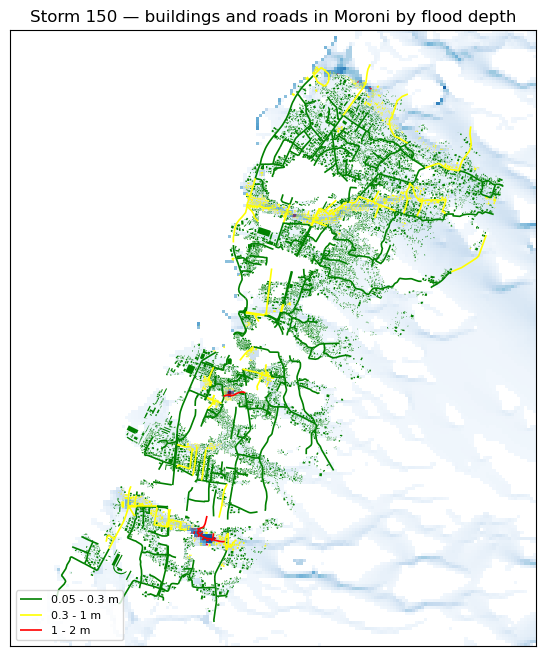

In [13]:
fig, ax = plt.subplots(figsize=(7, 8))
left, bottom, right, top = rasterio.transform.array_bounds(rows, cols, zarr_transform)
ax.imshow(shown, cmap="Blues", vmin=0, vmax=float(one_storm.max()),
          extent=(left, right, bottom, top))

for value, colour, _floor in DEPTH_BANDS:
    subset = features[features.band == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.2, label=BAND_LABEL[value])

ax.set_title(f"Storm {STORM} — buildings and roads in {attrs['admin_unit']['name']} by flood depth")
ax.set_xticks([]); ax.set_yticks([])
handles, labels = ax.get_legend_handles_labels()        # polygons and lines share a label
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="lower left", fontsize=8)
plt.show()

Only features that reach a band are drawn. Dry ones are the large majority and add
nothing a basemap does not already show — dropping them also shrinks the payload from
tens of thousands of features to a few thousand, which matters when it is re-fetched
every time the storm changes.

## 8. Impact across the library

Section 4 paid for the pairing once. Re-using it, sampling another storm costs one
chunk read and one pass over the pairs, so sweeping the library is cheap. Because the
magnitudes are real rainfall totals, the x-axis below is in millimetres and means what
it says.

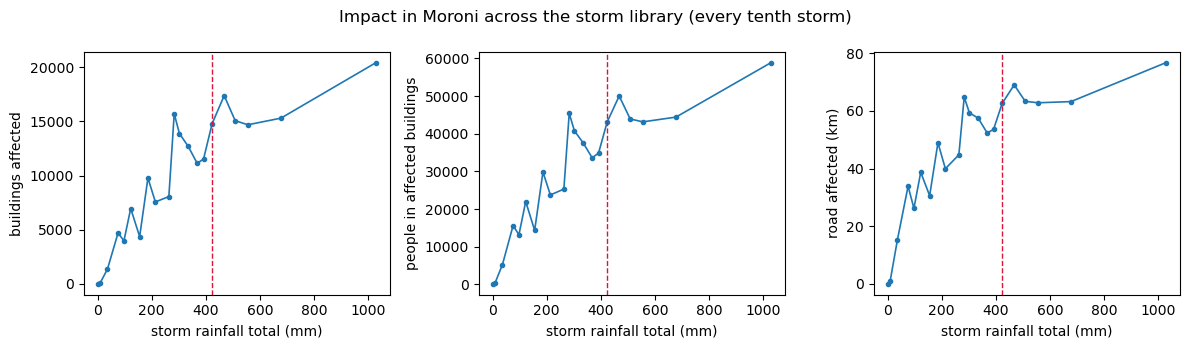

In [14]:
sweep = list(range(1, 200, 10)) + [199]
records = []
for i in sweep:
    band = classify_depth(feature_max_depth(i))
    hit = features[band > 0]
    records.append({"storm": i, "magnitude_mm": index.magnitude_mm[i],
                    "buildings": int((hit["type"] == "building").sum()),
                    "population": hit.population_per_building.sum(),
                    "roads_km": hit.road_length_m.sum() / 1000})
across = pd.DataFrame(records).set_index("storm")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col, label in zip(axes, ["buildings", "population", "roads_km"],
                          ["buildings affected", "people in affected buildings", "road affected (km)"]):
    ax.plot(across.magnitude_mm, across[col], marker="o", ms=3, lw=1.2)
    ax.axvline(index.magnitude_mm[STORM], color="crimson", ls="--", lw=1)
    ax.set_xlabel("storm rainfall total (mm)"); ax.set_ylabel(label)
fig.suptitle(f"Impact in {attrs['admin_unit']['name']} across the storm library (every tenth storm)")
fig.tight_layout(); plt.show()

The curves are not monotonic. The library is sorted by the commune-mean rainfall
total, but the flooded footprint depends on *where* in the commune the rain fell and
how fast, so a larger total does not guarantee more buildings under water. Magnitude
orders the library; it does not order the impact. That is why the forecast matches a
member to a storm by total and then reads the impact off the depth map, never off the
magnitude.

## 9. From library to forecast: rebuilding Exercise 3's raster

A forecast cycle does not compute new flood maps. Each of its 50 rainfall members has
a total over the commune; the member is matched to a library storm, and that storm's
depth map stands in for the member. **P(depth ≥ 30 cm)** at a cell is then the share
of the 50 members whose matched storm floods that cell to 30 cm — which is what the
probability rasters of Exercise 3 hold.

For the Comoros this can be checked rather than asserted. The cycle publishes
`member_decisions.csv` **for this commune**, and it records the storm each member was
matched to, so the reconstruction below can be compared cell for cell against the
`prob_depth_ge_30cm` raster the run shipped.

The matching rule is worth reading off the data rather than guessing. `p_rule` says
`pluvial_band` for every member, and the matched storm's magnitude is always *at or
above* the member's total — it is the smallest library storm that covers the member,
a deliberately conservative ceiling. Guessing "nearest magnitude" instead reproduces
only about 60% of the choices.

In [15]:
decisions = pd.read_csv(f"{CYCLE_ROOT}/fim/{UNIT}/stream_sat_stormlab/member_decisions.csv")
print(f"{len(decisions)} forecast members; rainfall totals "
      f"{decisions.total_mm.min():.1f} to {decisions.total_mm.max():.1f} mm")
print(f"matching rules used: {decisions.p_rule.unique().tolist()}")

# The run's own answer: p_storm names the scenario, index.csv gives its position.
position_of = dict(zip(index.storm_id, index.storm_index))
decisions["matched_storm"] = decisions.p_storm.map(position_of).astype(int)
print(f"distinct library storms matched: {decisions.matched_storm.nunique()} "
      f"for {len(decisions)} members")

# Read the rule off the data instead of assuming it.
order = index.magnitude_mm.to_numpy()
ceiling = np.searchsorted(order, decisions.total_mm.to_numpy(), side="left")
nearest_pos = np.clip(np.searchsorted(order, decisions.total_mm.to_numpy()), 1, len(order) - 1)
closer_below = np.abs(order[nearest_pos - 1] - decisions.total_mm) <= np.abs(order[nearest_pos] - decisions.total_mm)
nearest = np.where(closer_below, nearest_pos - 1, nearest_pos)
print(f'  "smallest storm >= member total" reproduces {100 * (ceiling == decisions.matched_storm).mean():.0f}% of the choices')
print(f'  "nearest magnitude"              reproduces {100 * (nearest == decisions.matched_storm).mean():.0f}%')

50 forecast members; rainfall totals 57.3 to 284.7 mm
matching rules used: ['pluvial_band']
distinct library storms matched: 16 for 50 members
  "smallest storm >= member total" reproduces 100% of the choices
  "nearest magnitude"              reproduces 60%


distinct probability values: 34   max 1.00
largest difference from the published raster: 0.000000
cells differing: 0 of 33,462


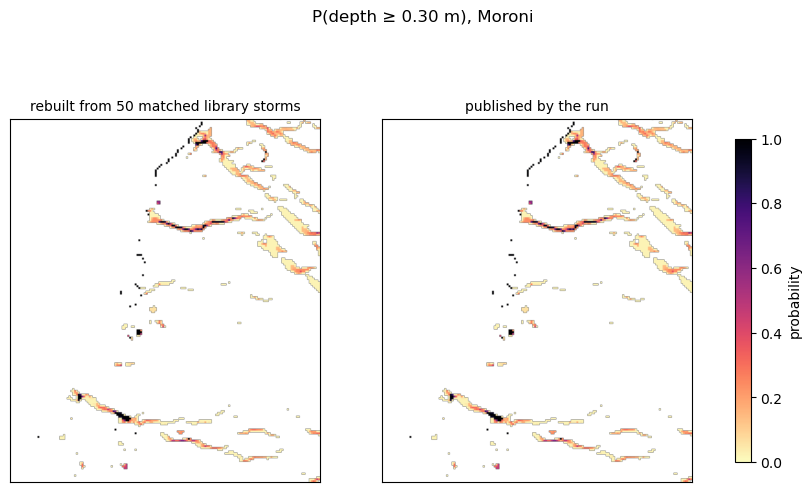

In [16]:
# P(depth >= 0.30 m) = share of members whose matched storm reaches 30 cm at the cell.
count = np.zeros((rows, cols), dtype="int32")
for i in decisions.matched_storm:
    count += np.asarray(depth[int(i)]) >= 0.30
prob_30 = count / len(decisions)

# The run shipped this raster. Rebuilding it is the check that the mechanism above is
# the mechanism that actually produced Exercise 3's inputs.
published = f"{CYCLE_ROOT}/fim/{UNIT}/stream_sat_stormlab/pluvial/prob_depth_ge_30cm.{CYCLE}.tif"
with rasterio.open(published) as ds:
    delivered = ds.read(1)

difference = np.abs(prob_30 - delivered).max()
print(f"distinct probability values: {len(np.unique(prob_30))}   max {prob_30.max():.2f}")
print(f"largest difference from the published raster: {difference:.6f}")
print(f"cells differing: {int((np.abs(prob_30 - delivered) > 1e-6).sum()):,} of {prob_30.size:,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, grid, title in zip(axes, [prob_30, delivered],
                           ["rebuilt from 50 matched library storms", "published by the run"]):
    im = ax.imshow(np.where(grid > 0, grid, np.nan), cmap="magma_r", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("P(depth ≥ 0.30 m), Moroni")
fig.colorbar(im, ax=axes, label="probability", shrink=0.7)
plt.show()

Two things that survive from this section:

- **Fifty members collapse to sixteen distinct storms.** Five rainfall realizations
  drive almost all the spread, so the probability is quantised — Exercise 3's rasters
  take few distinct values, and that is why, not a rounding artefact.
- **The reconstruction is exact.** Every cell of the published raster is reproduced,
  which means the mechanism described here *is* the mechanism, not a plausible story
  about it. If you change the matching rule to "nearest" the agreement collapses, and
  that is the fastest way to see how much the rule matters.

## 10. Building the Comoros storm plugins

Everything above runs here, in a notebook. To put it on a dashboard the same code has
to become a **plugin**: an installable Python package that TethysDash finds on its own
and runs for the frontend.

`tgf_wmo_plugins` ships a storm family — `uffis_storm_card_*`,
`uffis_storm_impact_summary_*`, `uffis_storm_impact_layer_*` — that does sections 3 to
6 for the Guatemala ensemble. Its store URL, storm count and magnitude labels are
module constants for that one store, so a Comoros variant is mostly a matter of making
those per-country and adding one argument. The list below doubles as a summary of what
this notebook hard-coded.

### What a Comoros variant declares

| what | where it comes from |
|---|---|
| the store URL | `fim_store_{UNIT}_v1.zarr`, section 1 — one per commune |
| the commune filter | `ADM3_PCODE = '{PCODE}'`, section 3 |
| the `index` dropdown | positions as values, `magnitude_mm` from `index.csv` as labels |
| the depth bands | `DEPTH_BANDS`, section 5 — shared, and meaningful to 2 m here |
| the population denominator | `population_per_building` summed over the commune, section 6 |

### Discovery — how the app finds it

A plugin is a class registered as an **Intake entry point** in `pyproject.toml`:

```toml
[project.entry-points."intake.drivers"]
uffis_storm_impact_summary_comoros = "tgf_wmo_plugins.storm_impact:StormImpactSummaryComoros"
uffis_storm_impact_layer_comoros   = "tgf_wmo_plugins.storm_impact:StormImpactLayerComoros"
uffis_storm_card_comoros           = "tgf_wmo_plugins.storm_card:StormCardComoros"
```

The key must match the class's own `name`, or the GUI lists a plugin it cannot load.

### The class — discovery properties, args, and one method

Comorian products are francophone, and French already exists in `STRINGS` because
Haiti uses it, so `LANG = "fr"` costs nothing:

```python
from tethysapp.tethysdash.plugin_helpers import TethysDashPlugin


class StormImpactSummaryComoros(TethysDashPlugin):

    # ---- discovery: how the GUI lists and presents this plugin -----------
    LANG = "fr"
    country = "comoros"
    name = "uffis_storm_impact_summary_comoros"    # must match the entry-point key
    label = f"{STRINGS[LANG]['storm_summary_label']} (Comores)"
    group = STRINGS[LANG]["group"]                 # the heading it is filed under
    tags = ["inondation", "impact", "zarr", "tempête", "tableau", "français"]

    # ---- what kind of visualization this is ------------------------------
    type = "table"
    # `type` picks the frontend renderer, and therefore dictates the shape run()
    # must return. One of: table, card, plotly, image, text, variable_input,
    # map, map_layer, custom.

    # ---- what the GUI asks the dashboard author to fill in ---------------
    args = {
        "commune": COMMUNE_OPTIONS,   # a list of {"value", "label"} -> a dropdown
        "index": STORM_OPTIONS,       # positions, labelled with magnitude_mm
    }
    # The arg *names* are the contract: they are the keys a dashboard stores, so
    # renaming one silently breaks every dashboard already using it. An argument a
    # plugin does not declare is simply absent at run time -- it does not raise, the
    # default is used, and the control appears to do nothing.

    def run(self):
        """Called once per request, and again whenever a bound arg changes."""

        commune = self.get_arg("commune", "KM274")
        index = self.get_arg("index", 150)
        # get_arg() reads a configured value. If the author bound this arg to a
        # variable input, the "${Storm}" reference is already resolved by now --
        # the plugin never sees the template syntax.

        gdf = banded_features(commune, index)
        # ^ sections 3 to 5: load the commune's features, sample the deepest water
        #   on each footprint, attach a depth band.

        # A `table` returns a title and a list of row dicts. Keys become the columns
        # in order; values are preformatted strings, because how a number should read
        # is a decision the renderer cannot make.
        return {"title": ..., "data": [{"Profondeur": "...", "Bâtiments": "..."}]}
```

### The commune argument is the new part

The existing storm plugins take one argument, `index`, because Guatemala has a single
store. Comoros writes one store per commune, so a second argument has to select it —
the same decision Exercise 3 faces, and it should be resolved the same way in both, or
a dashboard ends up with two controls that mean the same thing and can disagree.

It also changes what can be cached. Section 4's (feature, cell) pairing is expensive
and storm-independent, so the plugins cache it — but it is *commune*-dependent, so the
cache key has to be the commune, not a module-level global.

### Map layers implement two methods, not one

A `map_layer` plugin is asked two different questions at two different times, so it
answers them separately:

```python
class StormImpactLayerComoros(TethysDashPlugin):
    name = "uffis_storm_impact_layer_comoros"
    type = "map_layer"
    dynamic_map_layer = True     # this flag is what enables fetch_features()
    args = {"commune": COMMUNE_OPTIONS, "index": STORM_OPTIONS}

    def run(self):
        """CONFIGURE time. Called once, when the author adds the layer.

        Returns the layer's *scaffold*, not its data: a name, a source binding,
        style rules and a legend. This is what the layer editor's
        "Fetch plugin defaults" button calls.
        """
        builder = LayerConfigurationBuilder(STRINGS[self.LANG]["storm_layer_name"], "GeoJSON")

        builder.set_plugin_source(self.name, self.received_args)
        # received_args, NOT self.args. self.args is the *schema*; the runtime
        # re-invocation needs the configured *values*, including any "${Storm}"
        # binding that still has to be resolved on each fetch.

        builder.set_style(...)    # rules keyed on the `banda` attribute
        builder.set_legend(...)   # what the map legend shows for this layer
        return builder.build()

    def fetch_features(self):
        """RUN time. Called on load, and again every time `${Storm}` changes.

        Returns GeoJSON. This is the only part that re-executes.
        """
        self.send_update("Échantillonnage des profondeurs...", percentage_complete=10)
        # send_update() streams progress to the tile over a WebSocket, so a recompute
        # that takes a few seconds looks busy rather than broken.

        gdf = banded_features(self.get_arg("commune", "KM274"), self.get_arg("index", 150))
        return {"type": "FeatureCollection",
                "features": [...],
                "crs": {"type": "name", "properties": {"name": "EPSG:4326"}}}
```

### One thing the Comoros forces that the other countries did not

That `"EPSG:4326"` in the returned CRS is not decoration. The receptors and the store
are **EPSG:5629** (Moznet / UTM zone 38S), and the frontend resolves only EPSG:4326 and
EPSG:3857 without proj4 — so the features have to be reprojected before they are
returned, or the layer loads and lands nowhere near the Indian Ocean. Guatemala
(EPSG:3857) and Antigua and Barbuda (EPSG:4326) never had to think about it.

This is also why a plugin is the answer rather than a plain map layer. TethysDash can
point a vector layer straight at a GeoPackage, but its loader pre-registers only the
WGS84 UTM zones with proj4, and 5629 is not one of them — the same geometry under a
different authority code.

### The three plugins built on this kind of data

| plugin | `type` | `run()` returns |
|---|---|---|
| `uffis_storm_impact_summary_*` | `table` | `{"title", "data": [row dicts]}` — the table from section 6 |
| `uffis_storm_impact_layer_*` | `map_layer` | a layer scaffold; `fetch_features()` then returns the GeoJSON behind section 7 |
| `uffis_storm_card_*` | `card` | `{"data": [{"color", "label", "value", "icon"}]}` — headline figures, no title |

### Why the two-method split earns its keep

`run()` fires once, when someone is configuring the dashboard. `fetch_features()`
fires on every change to a bound variable. Putting the style and legend in `run()`
means they are computed once and stored with the dashboard, so changing the storm
re-runs only the part that actually depends on the storm.

All three plugins import one core module that caches the storm-independent step:
building the (feature, cell) pairs is paid once per commune per process — section 4 —
and changing the storm re-reads one chunk and re-runs a single pass over the pairs.

### Things to try

- Change `STORM` in section 1 and re-run. Storms 0–2 are the dry baseline — what you
  see there is Moroni's permanent standing water, not flooding. Storm 150 never
  reaches the top depth band: only seven of the 200 put any water above 2 m (storm
  137, and 194 through 199), so that row stays empty unless you pick one of them.
  Storm 199 is the largest in the library, at 2.58 m.
- Change `UNIT` to another commune — `KM271_BambaoYaHari`, `KM283_OichiliYamboini`,
  `KM321_Fomboni` on Moheli — and re-run the whole notebook. Nothing else has to
  change: the commune population, the island file and the member decisions are all
  derived from it. Note that 33 of the 55 stores were still uploading when this was
  written, so a commune may not resolve.
- Change the `DEPTH_BANDS` bounds. What happens to the table if you add a
  `1.5 m or more` band? Try the same experiment against an Antigua and Barbuda store,
  where depth is packed into a byte and saturates at 2.55 m, and see which bands stop
  meaning anything.
- Section 4 takes the **maximum** depth over each footprint. Try the mean instead
  (`np.add.at` and a count) and see how the table changes. Which is the more
  defensible number to give a decision-maker?
- In section 9, replace the run's own `matched_storm` with the `nearest` array
  computed beside it and re-run. The published raster is no longer reproduced. How
  wrong does the impact table get, and would you have noticed without the comparison?
- Compare the `band` this notebook assigns with the `risk_label` the run wrote into
  the geopackage. They answer different questions — depth in one storm, against
  likelihood crossed with severity across the whole forecast. Which one belongs on a
  warning, and which on a briefing?
- The Comoros chain is pluvial only (`hazards_enabled` in `pf_summary.json`). What
  would change in sections 4 to 6 if an island model were later run with river inflow?